In [57]:
import kaolin
import nibabel as nib
import pyvista as pv
import numpy as np
import torch
import matplotlib.pyplot as plt 
import trimesh

from kaolin.ops.conversions import voxelgrids_to_trianglemeshes

In [2]:
ixi_img = nib.load('IXI002-Guys-0828-T1.nii.gz')
ixi_img_data = ixi_img.get_fdata()
ixi_img_data.shape

(256, 256, 150)

In [68]:
verts, faces = voxelgrids_to_trianglemeshes(torch.Tensor(ixi_img_data).unsqueeze(1).to(torch.device('cuda:1')))

In [89]:
verts[5].cpu().numpy().shape

(2610, 3)

In [90]:
faces[5]

tensor([[   2,    1,    0],
        [   3,    1,    2],
        [   6,    7,    4],
        ...,
        [2608, 2604, 2605],
        [2608, 2605, 2609],
        [2609, 2605, 2603]], device='cuda:1')

In [95]:
torch.ones((4,8))

tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

In [74]:
for i, j in zip(verts[:5], faces[:5]):
    print(i.shape, j.shape)

torch.Size([2106, 3]) torch.Size([3708, 3])
torch.Size([1956, 3]) torch.Size([3546, 3])
torch.Size([1889, 3]) torch.Size([3456, 3])
torch.Size([2537, 3]) torch.Size([4714, 3])
torch.Size([2309, 3]) torch.Size([4314, 3])


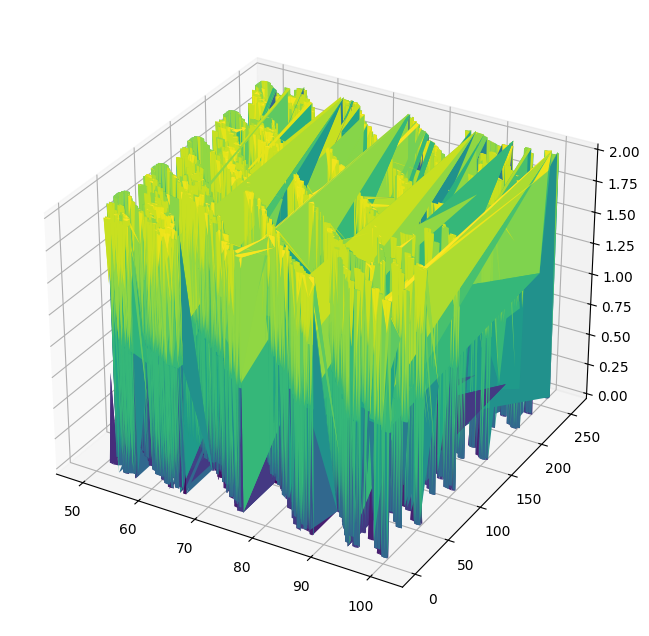

In [99]:
idx = 205

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
mesh = ax.plot_trisurf(verts[idx][:, 0].cpu(), verts[idx][:, 1].cpu(), verts[idx][:, 2].cpu(),
                      triangles=faces[idx].cpu(),
                      cmap='viridis',
                      alpha=1.0)
